<a href="https://colab.research.google.com/github/Aadya1504/OutageSense/blob/main/Isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving metrics_dataset.csv to metrics_dataset (2).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
df = pd.read_csv('/content/metrics_dataset (1).csv')
df.head()

,cpu_usage,memory_usage,disk_usage,network_latency,pod_restarts
0,55.804250,26.884518,66.173292,70.705869,3
1,43.884243,79.800997,41.853262,78.698888,1
2,37.949039,25.468240,50.354193,51.227010,0
3,39.140739,21.354115,23.672877,8.450503,2
4,10.000756,36.147185,17.143480,90.417460,2



Anomaly Count:
anomaly
0    4987
1     263
Name: count, dtype: int64


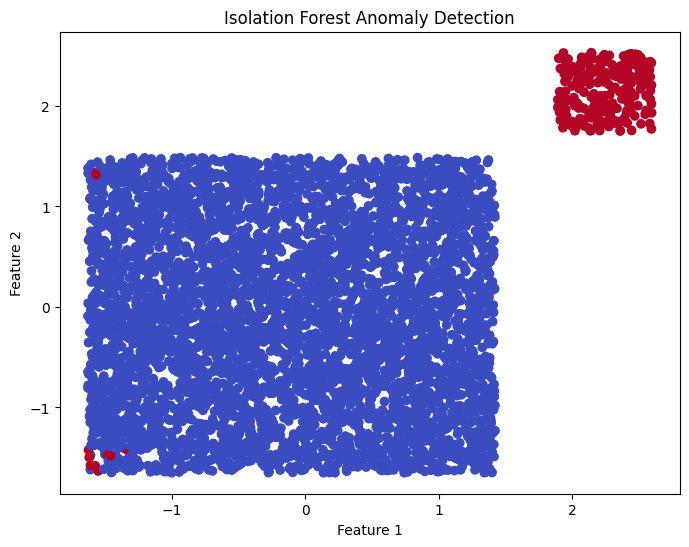


Results saved as anomaly_results.csv


In [ ]:
df = df.dropna()

# -------------------------------
# Select Numeric Features
# -------------------------------
X = df.select_dtypes(include=[np.number])

# -------------------------------
# Normalize Data
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Train Isolation Forest Model
# -------------------------------
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

# -------------------------------
# Predict Anomalies
# -------------------------------
df['anomaly'] = model.predict(X_scaled)

# Convert labels
df['anomaly'] = df['anomaly'].map({1:0, -1:1})

print("\nAnomaly Count:")
print(df['anomaly'].value_counts())

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=df['anomaly'],
    cmap='coolwarm'
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# -------------------------------
# Save Results
# -------------------------------
df.to_csv("/content/anomaly_results.csv", index=False)

print("\nResults saved as anomaly_results.csv")


In [ ]:
df['anomaly_score'] = model.decision_function(X_scaled)

In [ ]:
df['anomaly'].value_counts()

,count
anomaly,
0,4987
1,263


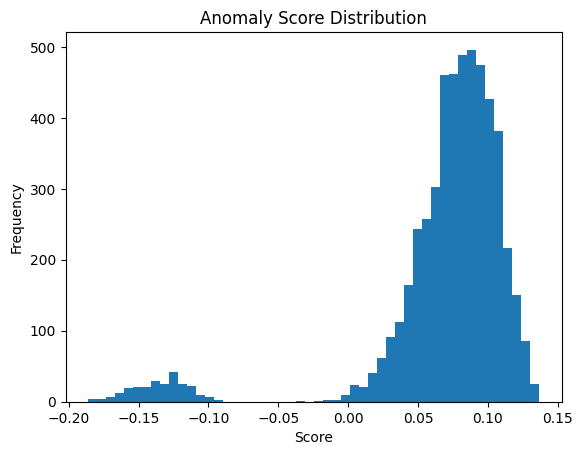

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['anomaly_score'], bins=50)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['anomaly'])
print("Silhouette Score:", score)

Silhouette Score: 0.7106129075787205
